
# <span style="color:rgb(213,80,0)">Examen de robótica \- Modelado de un robot SCARA</span>

## Introducción

La descripción matemática de la mecánica de un robot es de suma importancia para la robótica, pues a través del cálculo de la cinemática y de la dinámica se llega a resultados que nos muestran cómo se va a comportar la cadena cinemática que estamos empleando. En este curso introductorio a la Robótica se ha brindado la aproximación general de la generación de modelos completos para describir a un robot manipulador, no obstante, como es un curso introductorio, los primeros casos de estudio deben simplificarse de alguna forma, debido lo rápido que crece la complejidad de los modelos para casos generales tridimensionales o con un número alto de elementos móviles.


Debido a esto, el caso de estudio aquí analizado será un robot con una cadena cinemática de tres eslabones y tres juntas rotacionales que se mueven en un solo plano, una configuración bastante simple y teórica de un sobot SCARA que nos permite aplicar los conocimeintos desarrollados en clase. Es de nuestro interés resolver las descripciones mecánicas directas e inversas de este robot debido a lo mucho que nos ayudará en la comprensión de los conceptos que justifican todos y cada uno de los procedimientos que se realizarán en el cálculo de los modelos mencionados.


Este reporte se compones de dos secciones primordiales. La primera es la parte de la cinemática del robot, que a la vez se divide en 6 subsecciones, cada una dedicada al modelo cinemático directo e inverso de la posición, a los modelos cinemáticos directo e inverso de la velocidad y a los modelos cinemáticos directo e inverso de las aceleraciones del robot. Para esta parte, se busca analizar los dos enfoques de diseño y control del robot, es decir, cuando se conoce cuál será la configuración interna de la cadena cinemática del robot y entonces es nuestro trabajo determinar qué puntos del espacio alcanzará, este enfoque es el modelo directo de la cinemática. El otro enfoque nos indica a qué pose y con qué vectores de velocidad y aceleración debe llegar el punto final del robot, lo que nos deja cómo trabajo determinar la configuración interna de orientación, velocidad angular y aceleración angular que deben alcanzar los actuadores de las juntas del robot, de tal forma que se logre replicar el vector de pose, velocidad y aceleración del efector final tal como se necesita. En general, la parte directa e inversa de la velocidad y de la acelereación del robot tienden a estar suamente relacionadas y basta con un despeje algebraico para pasar de un enfoque al otro. No obstante, es muchon más difícil con el modelo cinemático y directo de la posición, pues algebraicamente no pueden relacionarse  de una forma tan directa como en los casos antes mencionados, lo que nos orilla a crear un modelo distinto que nos lleve a la infromación requerida. Este problema se ha afrontado con éxito y se muestra en las secciones posteriores a esta introducción.


El desarrallo de este modelado matemático del robot implica el uso de herramientas matematicas de complejidad moderada pero que son sumamente necesarias entender, pues no basta con programar el algoritmo de cálculo si no se entiende el tranfondo teórico de cada operación. Una de las herramientas matemáticas más importantes usadas en este modelado será las matrices de transformación homógeneas, la matriz Jacobiana del vector de postura de robot, su inversa, así como el uso repetido de sistemas de referencias, vectores descritos bajo distintos sistemas y porpiedades fñisicas mecánicas, como el Lagrangiano.


En este informe también se abarca el cálculo de los pares de los acutadores de las juntas del robot a través de las ecuaciones de Eüler\-Lagrange, cálculo que contempla los resultados obtenidos en la en la parte de la cinemáticaa, pues a través de las posiciones, las velocidades y las aceleraciones resultantes se debe estimar la potencia que debería tener cada actuador para generar estas condiciones cinemáticas además de los efectos de fuerza por la interacción de los distintos eslabones, su masa, su inercia, su peso y su geometría, lo que nos orilla a un cálculo un poco más complejo pero que es capaz de plantear una buena estimación de las fuerzas y la energía que tendrá el sistema mecánico total del robot. Al igual con en el caso de la cinemática, se tienen dos enfoques posibles: el enfoque directo contempla que conocemos todas las condicones de movimiento y los efectos de las propiedades físicas de cada eslabón en el movimiento del sistema total del robot, además de la fuerza externa que el robot debe tolerar parqa operar de una buena forma, de tal forma que con estos parámetros podemos calcular la magnitud de los pares que debe tener cada junta para que el movimiento sea posible; el segundo enfoque, por el contrario, plantea que ya se conoce el vector de pares dentro de la cadena cinemática, entoneces lo que se debe estimar son las codiciones de trabajo que puede tolerr el robot, descrubiendo la magnitud de las fuerzas externas máximas que pueden actuar sobre nuestro robot.


Aunque se sabe que tenemos una notación especial para los vectores y las matrices, donde se indica la base en la que se expresan y el sistema al que hacen referencia, en este caso se tuvo que modificar un poco para simplificar la escritura de este informe, por ello, todos lo vectores y matrices se escribirán como $A_{n,m}$, donde $n$ es el sistema desde donde se construye dicho vector o matriz y $m$ es el sistema que está describiendo. Para el caso de las matrices de transformación, n representa el sistema al que queremos llegar, y m es el sistema que se quiere describir.


EL objetivo principal de este modelo del robot es generar la docuemntación de diseño del robot, confirmando los modelos teóricos conocidos y resolviendo los distintos problemas que requiere este trabajo, con el fin de simular un robot como el que se analiza.

### Definición de funciones

Analizando la cadena cinemática del robot SCARA, como se muestra en el diagrama, es necesario crear sistemas de referencia sobre cada junta rotacional que se alinee con la orientación del eslabón al que se desea seguir, así como otro sistema de referencia en el extremo de la cadena cinemática que defina la posición y orientación del punto P que vamos a analizar, que sería el punto donde se instalaría una herramienta y por lo tanto, es el punto de mayor interés, pues nos importa controlar cómo se mueve y si alcanzaría la posición deseada. La creación de los sistemas de referencia es necesario porque simplifica la descripción de lo que le sucede a cada cuerpo o eslabón. No obstante, cada marco de referencia plantea un sistema desde el cual se pueden medir todos los cuerpos así como sus propiedades y las magnitudes físicas que determinan su cinemática y su dinámica.


En principio, sabemos que las magnitudes físicas no cambiarían en sí, pero la descripción desde distintos sistemas de referencia brinda cambios en los valores que las caracterizan, porque cada sistema tendrá una forma distinta de describir su espacio. Debido a esta restricción, se debe plantear un sistema inercial, un sistema de referencia estándar desde el cual se logre describir todos y cada uno de las magnitudes físicas de toda la cadena cinemática, con la diferencia que, al ser una sóla descripción para todos los cuerpos, se pueden operar sin restricciones.


Debido a estas condiciones que nos ayudan a describir de una forma simplificada cada cuerpo desde su propio sistema de referencia para después unificar las descripciones desde un sistema de referencia general, es necesario definir a la función tranformación homógenea general, $T_{i,j}$, una función matricial que toma 6 parámetros, tres distancias de posición $x_{i,j} ,y_{i,j} ,z_{i,j}$, y tres ángulos de orientación, $g_{i,j}$ asociado a un giro respecto al eje $\hat{\mathit{\mathbf{x}}}$, $b_{i,j}$ asociado a un giro respecto al eje $\hat{\mathit{\mathbf{y}}}$ y $a_{i,j}$ asociado a un giro respecto al eje $\hat{z}$, así mismo, se compone de un vector de perspectiva $\left\lbrack 0\;0\;0\right\rbrack$, y un factor de escala $\left\lbrack 1\right\rbrack$, que complementan el arreglo en información, a la vez que forman una matriz cuadrada invertible. El propósito de esta función es facilitar la transcisión entre sistemas de referencia, pues a través de los elementos que la componen, podemos pasar de la descripción hecha bajo un sistema de referencia $j$ hacia una descripción bajo un sistema de referencia $i$.


In [1]:
%Deficición de la función de manera símbolica
syms Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) P_i_j
%Definición de la transformación homogénea general
Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) = [cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j) x_i_j; sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j) y_i_j; -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j) z_i_j; 0 0 0 1]


Esta función, definida por los parámetros ya mencionados, nos brinda mucha información que se puede desgrosar de esta manera: la matriz que se forma con las tres filas superiores y las tres columnas a la izquierda, ${\mathit{\mathbf{R}}}_{i,j}$, es la matriz de rotación que relaciona a los sistemas involucrados en la transformación y determina como pasar de la orientación de $j$ a la orientación de $i$.


In [2]:
R_i_j=[cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j); sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j); -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j)]


El vector que se forma con la última columna y las primeras tres filas, es el vector de posición, que nos indica las coordenadas de un punto descrito bajo el sistema de referencia $j$ y que deben tomarse en cuenta cuando pasemos al sistema de referencia $i$. Este vector ${\mathit{\mathbf{P}}}_{\mathit{\mathbf{i}},\mathit{\mathbf{j}}}$ se muestra a continuación.


In [3]:
P_i_j=[x_i_j;y_i_j;z_i_j]


Con esta información, se tiene la herramienta más indispensable para operar las distintas descripciones bajo distintos sistemas de referencia que se harán a lo largo de esta descripción cinemática y dinámica del robot SCARA.

## Modelado del robot Scara

<p style="text-align:left">
   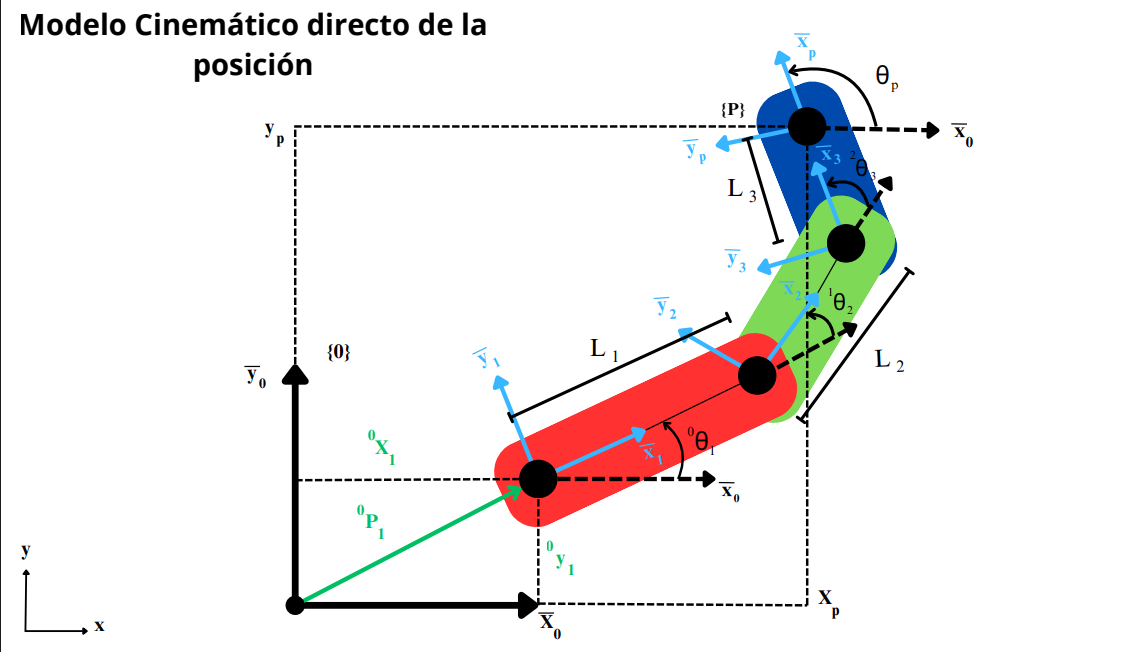
</p>

### Planteamiento del modelo cinemático directo de la posición

La descripción de la posición a través del modelo cinemático directo plantea el siguiente problema: se tienen los ángulos de las juntas que conforman la cadena cinemática del robot, ¿Cuál será la postura que tome la configuración del robot con estos parámetros definidos? Por ello, es de sumo interés conocerlo y saber manipular este modelo, pues a través de su descripción podríamos conocer el espacio al que sí puede llegar y en el que puede operar esta cadena cinemática.


El primer paso fundamental para comenzar la descripción cinemática directa de la cadena del robot SCARA es construir las bases que siguen el movimiento de cada eslabón que la compone. De este modo, tenemos la base {1} del cuerpo uno, la base {2} para el segundo cuerpo, la base {3} para el último eslabón y, por último, el sistema {P}, aquel sistema que sigue el movimiento, posición y orientación del punto final de la cadena, punto que es de suma importancia controlar porque representa todos los puntos que puede alcanzar en sí la operación del robot. A los mencionados sistemas de referencia se debe agregar el sistema {O}, la base inercial general desde la cual se buscará hacer todas las operaciones y cálculos.


Debido a lo mencionado en la sección anterior, debemos crear las funciones de transformación que nos permitan cambiar de un sistema a otro, con el fin de homogeneizar las descripciones físicas y poder operarlas entre sí. Gracias a la definción de la Transformación Homogénea General, se puede, en primera instancia definir la tranformación del sistema {1} al sistema inercial {O}, ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},1}$, transformación que se define como una traslación desde el origen de {O} hasta las coordenadas $\left(x_{O,1} ,y_{O,1} \right)$, con un giro respecto al eje $\hat{z}$, de magnitud $\theta_{O,1}$. La transformación ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},1}$ se muestra a continuación.


In [4]:
syms x_O_1 y_O_1 theta_O_1 L_2 theta_1_2 L_3 theta_2_3 L_1

T_O_1 = Tij(x_O_1,y_O_1,0,0,0,theta_O_1)


Una de las ventajas de trabajar con las matrices de transformación homógenea, además de ser invertibles y bastantes útiles en cuanto a la información que brindan, es que tienen la siguiente propiedad:


$${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},\mathit{\mathbf{n}}} ={\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},1} \times {\mathit{\mathbf{T}}}_{1,2} \times \ldotp \ldotp \ldotp \times {\mathit{\mathbf{T}}}_{\mathit{\mathbf{n}}-2,\mathit{\mathbf{n}}-1} \times {\mathit{\mathbf{T}}}_{\mathit{\mathbf{n}}-1,\mathit{\mathbf{n}}}$$

Donde {n} es un sistema de referencia del cual nos interesa conocer su transformación a un sistema inercial {0}, pero que tienen n\-1 sistemas intermedios que no permiten generar una transformación directa.


Esta propiedad nos permite generar transformaciones intermedias que en principio pueden ser más simples, y posteriormente multiplicarlas para definir una tranformación total desde el sistema {n} hasta el sistema inercial {O}. Esta propiedad es la que se usará para obtener la transformación desde el sistema del punto final de la cadena cinemática {P} hasta el sistema inercial {O}, de tal forma que se pueda obtener una descripción de la posición y orientación de {P} completa desde un sistema donde ya no hay puntos o distancias relativas a sistemas intermedios o que cambian constantemente de ubicación y orientación. Por ello, la trasformación ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}}$ se define de la siguiente manera:


$${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}} ={\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},1} \times {\mathit{\mathbf{T}}}_{1,2} \times {\mathit{\mathbf{T}}}_{2,3} \times {\mathit{\mathbf{T}}}_{3,\mathit{\mathbf{P}}}$$

De acuerdo a esta definción, es necesario calcular las trasnformaciones homógeneas de cada cambio de sistema de referencia intermedio. ${\mathit{\mathbf{T}}}_{1,2}$ se define gracias a una traslación de magnitud $L_1$ en el eje $\hat{\;\mathit{\mathbf{x}}{\;}_1 }$, y un giro $\theta {\;}_{1,2}$ respecto al eje $\hat{\mathit{\mathbf{z}}{\;}_1 }$. Por ello, ${\mathit{\mathbf{T}}}_{1,2}$ es:


In [5]:
T_1_2 = Tij(L_1,0,0,0,0,theta_1_2)


${\mathit{\mathbf{T}}}_{2,3}$ se define como una traslación de magnitud $L_2$ en el eje $\hat{\;\mathit{\mathbf{x}}{\;}_2 }$, y un giro $\theta {\;}_{2,3}$ respecto al eje $\hat{\mathit{\mathbf{z}}{\;}_2 }$. Por ello, ${\mathit{\mathbf{T}}}_{2,3}$ es:


In [6]:
T_2_3 = Tij(L_2,0,0,0,0,theta_2_3)


Por último, ${\mathit{\mathbf{T}}}_{3,\mathit{\mathbf{P}}}$ se define sólo con una traslación de magnitud $L_3$ en el eje $\hat{\;\mathit{\mathbf{x}}{\;}_3 }$, en la que no existe un cambio de orientación del sistema {P} respecto al sistema {3}, debido a que los dos sistemas se encunetran montados sobre el mismo cuerpo, pero no en el mismo punto. Por ello, ${\mathit{\mathbf{T}}}_{3,P}$:


In [7]:
T_3_P = Tij(L_3,0,0,0,0,0)


Finalmente, ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}}$ se define como la multiplicación de las matrices de transformación intermedias, desde ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},1}$ hasta ${\mathit{\mathbf{T}}}_{3,\mathit{\mathbf{P}}}$. Como el fin de operar con estas transformaciones y los cambios de sistemas de referencia es obtener una descripción detallada de la posición y orientación del punto final **P** de la cadena cinemática, en función de la configuración interna de las juntas, es decir, de los ángulos que toman las juntas rotacionales, al obtener la tranformación ${\mathit{\mathbf{T}}}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}}$ logramos este objetivo; no obstante, se debe recalcar que la matriz de transformación no es en sí el vector de postura del robot, pero la información que contiene sí compone al vector que realmente describe cómo está posicionado y orientado el punto final del robot en función de la configuración interna (en este caso, en función de los ángulos que toman las juntas del robot).


In [8]:
T_O_P = simplify(T_O_1*T_1_2*T_2_3*T_3_P)

#### Vector de postura del robot

Se sabe que el vector de postura de un robot está definido por 6 parámetros, 3 de posicón y 3 de orientación.


$$\xi {\;}_{O,P} =\left\lbrack \begin{array}{c} P_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack =\left\lbrack \begin{array}{c} x_{O,P} \newline y_{O,P} \newline z_{O,P} \newline \phi {\;}_{O,P} \newline \psi {\;}_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack$$

Para el caso analizado, al ser una descripción de un robot SCARA plano en el plano XY, la coordenada $z_{O,P}$ no es de interés, pues cerá nula. Por otro lado, no tenemos descripción de cambios de orientación respecto a los ejes $\hat{\mathit{\mathbf{x}}} \;y\;\hat{\mathit{\mathbf{y}}\;}$, por lo que la descripción de la orientación sólo estaría definida por el ángulo $\theta {\;}_{O,P}$. Es decir, el vector de postura del punto final de la cadena cinématica quedará definido como:


$$\xi {\;}_{O,P} =\left\lbrack \begin{array}{c} x_{O,P} \newline y_{O,P} \newline \theta {\;}_{O,P}  \end{array}\right\rbrack$$

Como se mencionó en la descripción de la forma general de la Transformación Homógenea, las coordenadas de posición son las tres primeras filas de la última columna que la compone. Por otro lado, el ángulo general que describe la orinetación de {P} desde {O} es en realidad la suma de los tres ángulos de las juntas que componen a la cadena cinemática, hecho que es bastante fácil deducir en el esquema de esta sección. Debido a esto, $\xi {\;}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}}$ es:


In [9]:
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]


La descripción de la postura, $\xi {\;}_{\mathit{\mathbf{O}},\mathit{\mathbf{P}}}$ se logra en función del vector $\mathit{\mathbf{q}}={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$, vector que contiene la configuración de las juntas del robot SCARA, hecho que es esperado en el modelo cinemático directo de las posiciones.

### Planteamiento del modelo cinématico inverso de las posiciones
<p style="text-align:left">
   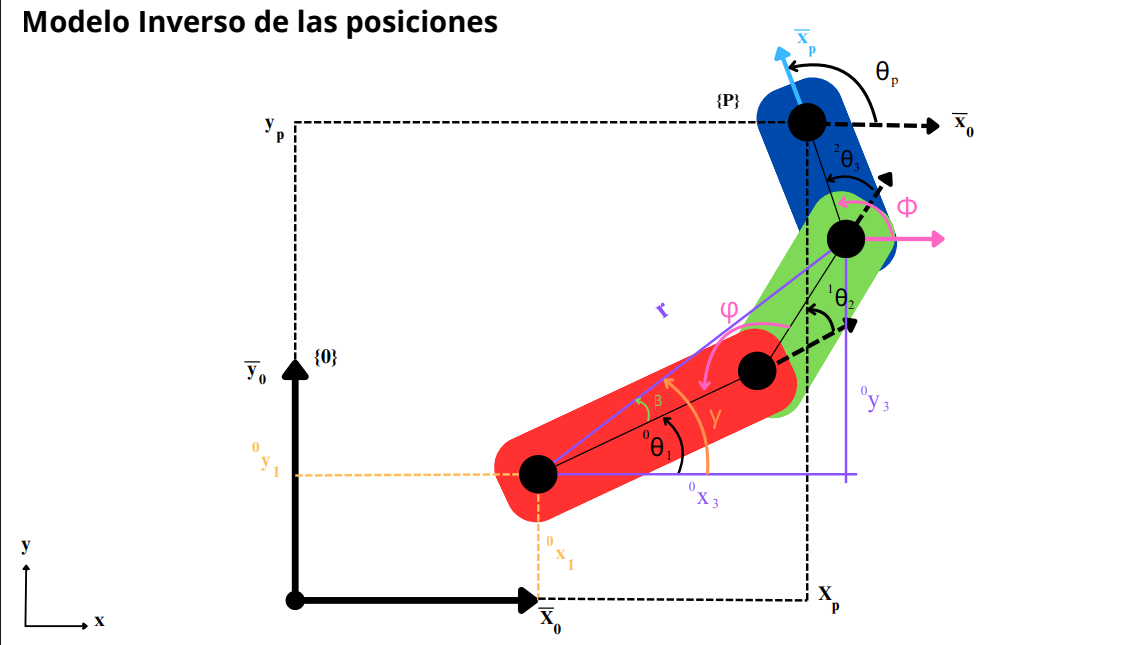
</p>


De forma contraria a lo que se planteó en el modelo cinemático directo, en la cinemática inversa se tiene un vector de pose $\xi {\;}_{O,P}$ que se quiere alcanzar (un vector distinto al resultado de la sección anterior, porque este vector tiene en sí valores propios que no están definidos en función del vector q) y este modelo debe encontrar los parámetros de  $\mathit{\mathbf{q}}={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ tal que se satisfaga la configuración de pose establecida.


In [10]:
syms x_O_P y_O_P theta_O_P
xi_O_P = [x_O_P; y_O_P; theta_O_P]


De forma general, el modelo cinemátcio inverso de las posiciones genera un problema mucho más complejo que en el caso directo. Existen restricciones matemáticas que nos impiden pasar de un modelo directo a un modelo inverso de la posición porque las ecuaciones de posición definidad en $\xi {\;}_{O,P} \left(q\right)$ no son lineales, pues incluyen funciones senoidales que complican la resolución. Se podrían emplear métodos numéricos pero estos fallarían porque la función que define la orientación en el vector de postura no es continuamente derivable, sin mencionar que los tiempos y recursos de cálculo serían muy grandes y crecerían más según aumente la complejidad del sistema a modelar.


Debido a este gran problema, generalmente se opta por métodos de modelado distintos. Uno de ellos consiste en la restricción del sistema, de tal forma que sea más simple obtener la información necesaria. La empleada en este caso, se basa en el desacoplamiento cinemático, el cual consiste en separar la cadena en dos secciones más simples.


Del diagrama correspondiente a esta sección, en el punto final P se debe alcanzar la configuración descrita por el vector $\xi {\;}_{O,P}$. Para ello, se analiza por separado la cadena cinemática que forman el primer y el segundo eslabón, estableciendo en la junta del segundo y el tercer eslabón el punto $P_{O,3}$, del cual se tiene la posición ${\mathit{\mathbf{P}}}_{O,3} ={\left\lbrack \begin{array}{ccc} x_{O,3}  & y_{O,3}  & 0 \end{array}\right\rbrack }^T$ y que forma el triángulo de hipotenusa r mostrado en la figura. Como es de suma importancia poner los parámetros de la cadena cinemática en función de los datos que conocemos, se definen a $x_{O,3} \;y\;y_{O,3}$ en función de $\xi {\;}_{O,P}$ y a partir de la relación geométrica del tercer eslabón con el punto $P_{O,3}$.


In [11]:
x_O_3 = x_O_P-L_3*cos(theta_O_P)

In [12]:
y_O_3 = y_O_P-L_3*sin(theta_O_P)


A partir de la imagen y por teorema de Pitágoras, se establece el valor de $r$.


In [13]:
r = sqrt((x_O_3)^2+(y_O_3)^2)


La longitud $r$ también forma parte del triángulo oblicuo que se forma al unir al primer eslabón de longitud $L_1$ y segundo eslabón $L_2$ con la distancia $r$, con el ángulo interno $\psi \;$ que es el complementario de $\theta {\;}_{1,2}$ y el ángulo $\beta \;$, que define la orientación de $r$ desde el eje simétrico del primer eslabón. Gracias a este triángulo, se puede establecer la ley de cosenos para $\psi \;$, que a la vez se define como $\psi =\pi -\theta {\;}_{1,2}$. Aunque incialmente la ley de cosenos aplica para $\psi \;$, cuando se obtiene el resultados $-\cos \left(\psi \;\right)$, se emplea la propiedad del coseno tal que $-\cos \left(\pi -\theta {\;}_{1,2} \right)=\cos \left(\theta {\;}_{1,2} \right)$. Debido a esto, la descripción del cosenos de $\theta {\;}_{1,2}$ queda como:


In [14]:
cos_theta_1_2=((r^2)-(L_1^2)-(L_2^2))/(2*L_1*L_2)


De la entidad pitágorica $\sin^2 \theta +\cos^2 \theta =1$ y de la definción anterior, podemos encontrar el valor del seno de $\theta {\;}_{1,2}$:


In [15]:
sin_theta_1_2=sqrt(1-(cos_theta_1_2))


Gracias a estas definciones, podemos obtener el valor del ángulo $\theta {\;}_{1,2}$ en función de las coordenadas de $\xi {\;}_{O,P}$, a través de la función atan2, que considera que cuadrante de las coordenadas se trabaja y nos brinda un resultado numérico válido para el modelo que se está desarrollando.


In [16]:
theta_1_2 = atan2(sin_theta_1_2,cos_theta_1_2)


De la imagen, sabemos que $\theta {\;}_{0,1} =\gamma -\beta \;$, que $\gamma =\textrm{atan}\left(\frac{y_{O,3} }{x_{O,3} }\right)$ y que $\beta \;$ se puede obtener a partir de la creación de un nuevo triángulo rectángulo, de hipotenusa $r$ y de catetos $L_1 +L_2 \cdot \cos \left(\theta {\;}_{1,2} \right)\;y\;L_2 \cdot \sin \left(\theta {\;}_{1,2} \right)$, tal que el valor de $\beta \;=\textrm{atan}\left(\frac{L_2 \cdot \sin \left(\theta {\;}_{1,2} \right)}{L_1 +L_2 \cdot \cos \left(\theta {\;}_{1,2} \right)}\right)$. Realizando los correspondientes cálculos y sustituciones, se obtiene:


In [17]:
beta=atan2(L_2*sin_theta_1_2,L_1+L_2*cos_theta_1_2)

In [18]:
gamma = atan2(y_O_3,x_O_3)

In [19]:
theta_O_1=gamma-beta


Por último, sabemos que el ángulo total $\theta {\;}_{O,P} =\theta_{O,1} +\theta {\;}_{1,2} +\theta {\;}_{2,3}$, una relación muy simple de la cual se puede ahora conocer $\theta {\;}_{2,3}$ conociendo los valores de $\theta {\;}_{1,2} \;y\;\theta {\;}_{2,3}$.


In [20]:
theta_2_3=theta_O_P-theta_O_1-theta_1_2


Con la obtención de los ángulos que componen al vector **q** en función de los parámetros de pose que deseamos alcanzar, ahora es posible definir al mismo vector **q** de configuración, tal que:


In [21]:
q=[theta_O_1;theta_1_2;theta_2_3]


Con este vector, se ha acabado el modelado cinemático inverso de la postura. Este modelo es sumamente útil para controlar de una forma más fácil los movimientos y psoturas del robot, indicandole una pose final a la que debe llegar y haciendo que el modelo determine cómo configurarse para lograr dicho cometido, optimiza los movimientos y permite una mejor planeación de ellos, con la desventajas de un aumento considerable de las matemáticas útilizadas para resolverse, con situaciones en las que incluso se puede llegar al mismo punto con diferentes configuraciones (soluciones múltilpes debidas a la no linealidad del problema), la existencia de puntos donde se perderían movimientos y grados de libertad, lo que implica un problema en el control de las velociades que eventualmente llevará a un alto costo computacional.

### Modelo cinemático directo de las velocidades
<p style="text-align:left">
   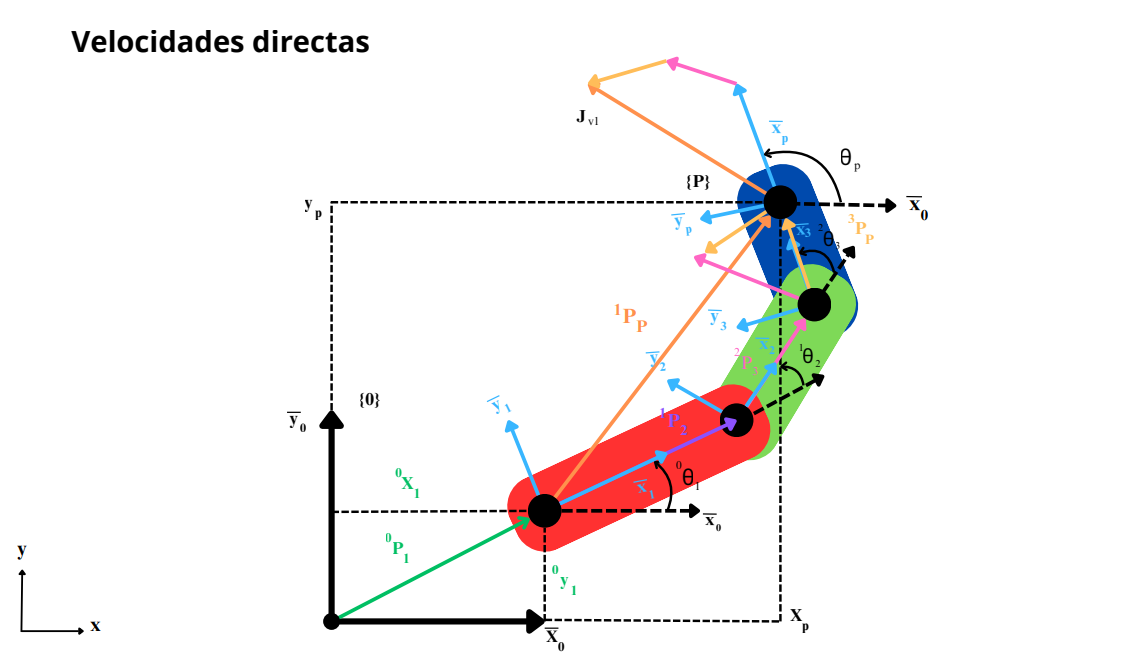
</p>


<p style="text-align:left">
   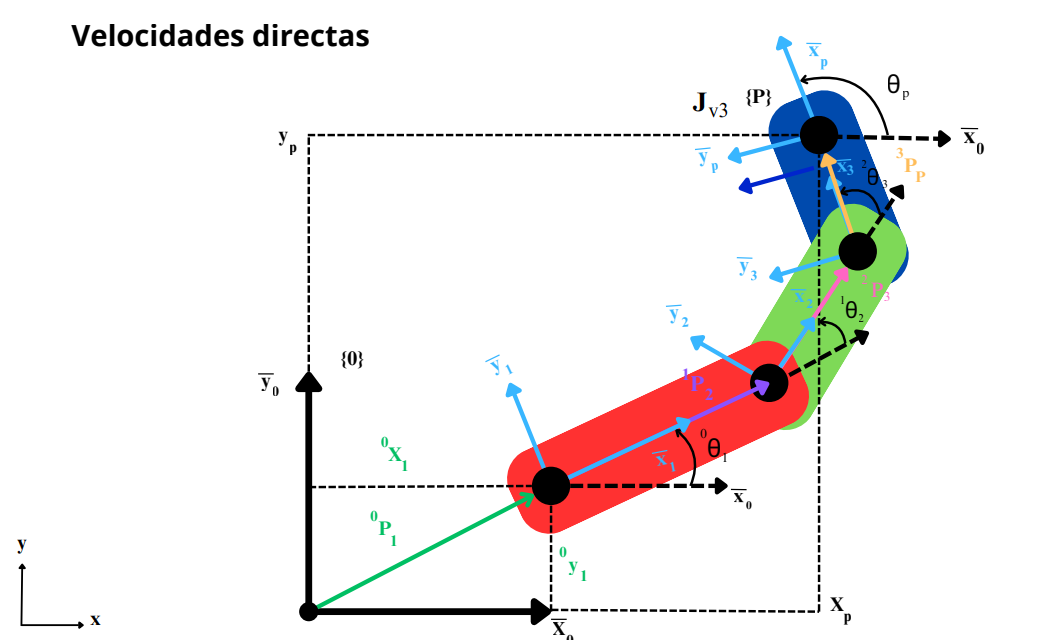
</p>


Partiendo de los resultados del modelo cinemático directo de la posición del robot:


In [22]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3 theta_O_1 theta_1_2 theta_2_3
xi_O_P = [T_O_P(1,4);T_O_P(2,4);theta_O_1+theta_1_2+theta_2_3]


Se define la matriz jacobiana del robot, una herramienta metemática creada por Carl G. Jacobi que nos permite, a través de derivadas parciales del vector de postura respecto a cada variable que compone el vector de configuración, en este caso $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$, para determianr el efecto que el movimento de cada articulación tiene sobre la velocidad lineal y angular del punto final de la cadena cinemática. A través de su cálculo se pueden determinar muchas propiedades del robot, una de ellas es la movilidad del robot y la capacidad que tiene para transmitir el movimento, su determinante es un valor escalar que nos arroja la una medida cuantitativa de la manipulabilidad del robot.


Con su cálculo y el uso de su matriz inversa se pueden determinar los modelos director e inversos de la cinemática de las velocidades y de las aceleraciones, así como presentar un puente entre las fuerzas exteriores aplicadas hacia un robot y los torques necesarios para generar su movimiento. Por definición, $J\left(\theta \;\right)=\left\lbrack \frac{\partial \;\xi {\;}_j \;}{\partial \;q_i }\right\rbrack$, por lo tanto, el jacobiano del robot SCARA analizado será:


In [23]:
J_theta = jacobian(xi_O_P,[theta_O_1, theta_1_2,theta_2_3])


Con la matriz Jacobiana y a través de la siguiente expresión $\dot{\;\xi \;} {\;}_{O,P} =J\left(\theta \right)\times \dot{\;q}$, con $\dot{\;q} ={\left\lbrack \dot{\;\theta } {\;}_{O,1} \;\;\;\dot{\;\theta \;} {\;}_{1,2} \;\;\dot{\;\theta \;} {\;}_{2,3} \right\rbrack }^T$ podemos calcular la velocidad angular y lineal al final de la cadena cinemática. Para esto, se usa la matriz jacobiana que depende de la configuración $q$ del robot, multiplicada por el vector de las velocidades angulares de la cadena cinemática, $\dot{\;q}$. Efectuando la correspondiente operación matricial, obtenemos el vector de velocidad de la postura del robot, donde tenemos dos velocidades lineales en dirección $\hat{x} \;y\;\hat{y\;}$, así como una velocidad angular total en el punto final {P}, elementos que componen al vector  $\dot{\;\xi \;} {\;}_{O,P} \left(q,\dot{\;q} \right)$, pues las velocidades son las que se presentarán al final de la cadena cinemática pero están descritas desde el sistema inercial {O}. El resultado se muestra a continucación.


In [24]:
xi_dot_O_P=J_theta*[theta_dot_O_1;theta_dot_1_2;theta_dot_2_3]

### Modelo cinemático inverso de las velocidades
<p style="text-align:left">
   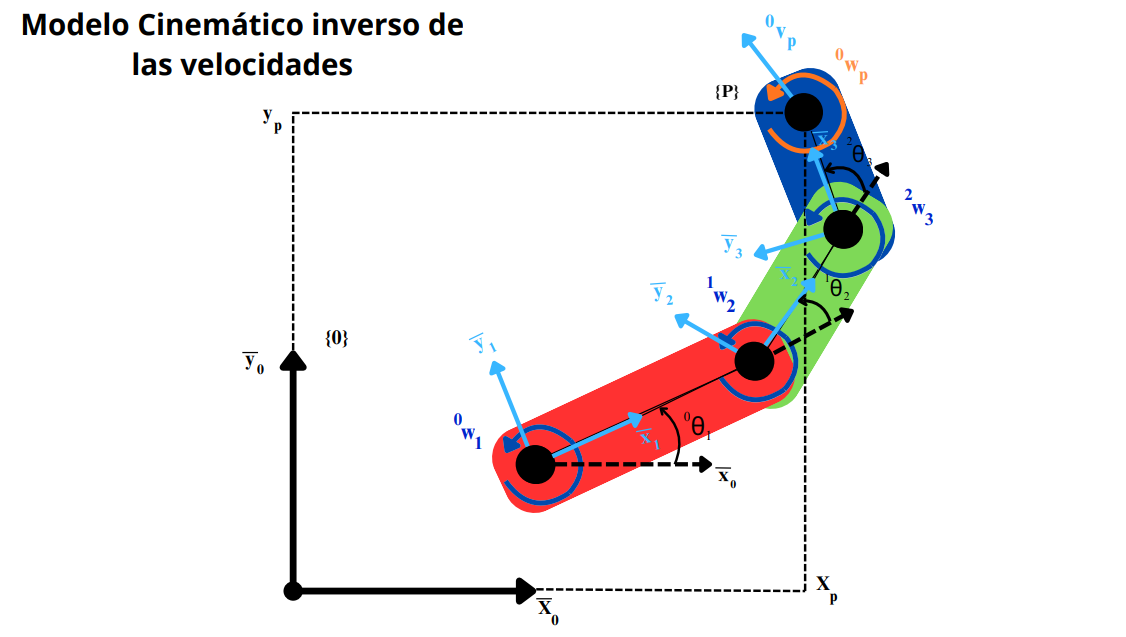
</p>


La matriz jacobiana es una matriz invertible de suma importancia que define al modelo inverso de las velocidades de un robot. El problema es el siguiente: se conoce un vector de velocidad que se debe cumplir para el movimiento de la cadena cinemática, pero se desconocen las velocidades angulares de cada junta rotacional de nuestro modelo SCARA. A diferencia del caso anterior, ahora es necesario determinar qué tán rápido o lento se debe accionar un motor en cada junta para lograr la velocidad deseada.


Del modelo cinemático directo de las velocidades, $\dot{\;\xi \;} {\;}_{O,P\;} =J\left(q\right)\dot{\;q}$, depenjando el vector derivado de la configuración del vector, $\dot{\;q} =J^{-1} \left(\theta \;\right)\dot{\;\xi \;} {\;}_{O,P}$.


La matriz jacobiana inversa es la clave que nos permite interpretar una velocidad deseada en el sistema {P} y que nos permite traducirlas a las velocidades angulares de cada junta rotacional. Es una pieza clave para establecer el control del movimento del robot y determinar si las velocidades propuestas son alcanzables. Un valor muy grande dentro de esta matriz indica que, para un leve movimiento de la cadena cinemática requiere en sí un gran trabajo o potencia en el actuador donde se muestra el resultado de gran magnitud. En este caso de interés, la matriz inversa del modleo es:


In [25]:
syms x_dot_O_P y_dot_O_P theta_dot_O_P
inv(J_theta)


Definiendo al vector de las velocidades deseadas para el punto P, $\dot{\;\xi \;} {\;}_{O,P}$:


In [26]:
xi_dot_O_P=[x_dot_O_P; y_dot_O_P; theta_dot_O_P]


De tal modo que la multiplicación de ambas matrices resulta en:


In [27]:
q_dot=J_theta\xi_dot_O_P


De este modo, se ha calculado al vector $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$, donde el resultado mostrado arriba indica el valor que debe tomar cada velocidad angular de cada junta, respectivamente, para alcanzar las condiciones declaradas en el vector de velocidad $\dot{\;\xi \;} {\;}_{O,P}$, resolviendo efectivmamente el problema que este modelo planteaba. Cabe mencionar que, para este modelo, $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ son de alguna forma valores ya conocidos, ya sea por el modelo directo o inverso de la cinemática de la posición del robot.

### Modelo cinemático directo de las aceleaciones

De igual forma que con las velocidades, este modelo hace uso de la matriz jacobiana, sólo que se debe agregar la definición de la derivada de esta misma, pues conocer la variación que tendrán las proyecciones de las velocidades tangenciales y angulares del movimiento del robot en el tiempo definen cómo el movimiento de cada cuerpo dentro de la cadena cinemática afecta a la aceleración terminal de la misma, por lo que es de suma relevancia analizarla. La matriz  jacobiana derivada puede entenderse como $\dot{J} \left(q,\dot{\;q} \right)=\frac{dJ\left(q\right)\;}{\;\textrm{dt}}=\frac{\partial \;J\left(q\right)\;}{\partial \;q_i }\dot{\;q\;} {\;}_i$. Por lo tanto, la matriz jacobiana derivada será:


In [28]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3
J_dot=diff(J_theta,theta_O_1)*theta_dot_O_1+diff(J_theta,theta_1_2)*theta_dot_1_2+diff(J_theta,theta_2_3)*theta_dot_2_3


De los resultados del modelo dinámico directo de la velocidad del punto final P, $\dot{\;\xi \;} {\;}_{O,P} =J\left(\theta \;\right)\times {\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T =J\left(\theta \;\right)\times \dot{\;q}$, al derivar y utilizar la regla de la cadena, obtendríamos $\ddot{\;\xi \;} {\;}_{O,P} =\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} +J\left(q\right)\times \ddot{\;q}$. En esta ecuación, se nos decribre que la aceleración en el punto final de la cadena cinemática del robot  está determinado por cómo interactúan en conjunto el resultado directo de la aplicación de aceleraciones angulares sobre las juntas del robot y el resultado de las aceleraciones inherentes que se generan por el moviento propio de cada eslabón, conocido por componerese de las aceleraciones centrñipetas y el efecto de Colioris, un efecto del movimiento que parece alterar el movimento lineal de un eslabón debido a una rotación previa. Gracias a estas definiciones, se puede calcular el vector $\ddot{\;\xi } {\;}_{O,P}$:


In [29]:
xi_dot_O_P=J_theta*[theta_dot_O_1;theta_dot_1_2;theta_dot_2_3];
xi_ddot_O_P=J_theta*[theta_ddot_O_1;theta_ddot_1_2;theta_ddot_2_3]+J_dot*xi_dot_O_P


Así, se consiguen las expresiones en función de la configuración de la postura $q={\left\lbrack \begin{array}{ccc} \theta {\;}_{O,1}  & \theta {\;}_{1,2}  & \theta {\;}_{2,3}  \end{array}\right\rbrack }^T$ y de las velocidades angulares de las juntas $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$ que definen cómo se acelera tangencialmente y rotacionalmete el punto P cuando se traslada de una configuración a otra.

### Modelo cinemático inverso de las aceleraciones
<p style="text-align:left">
   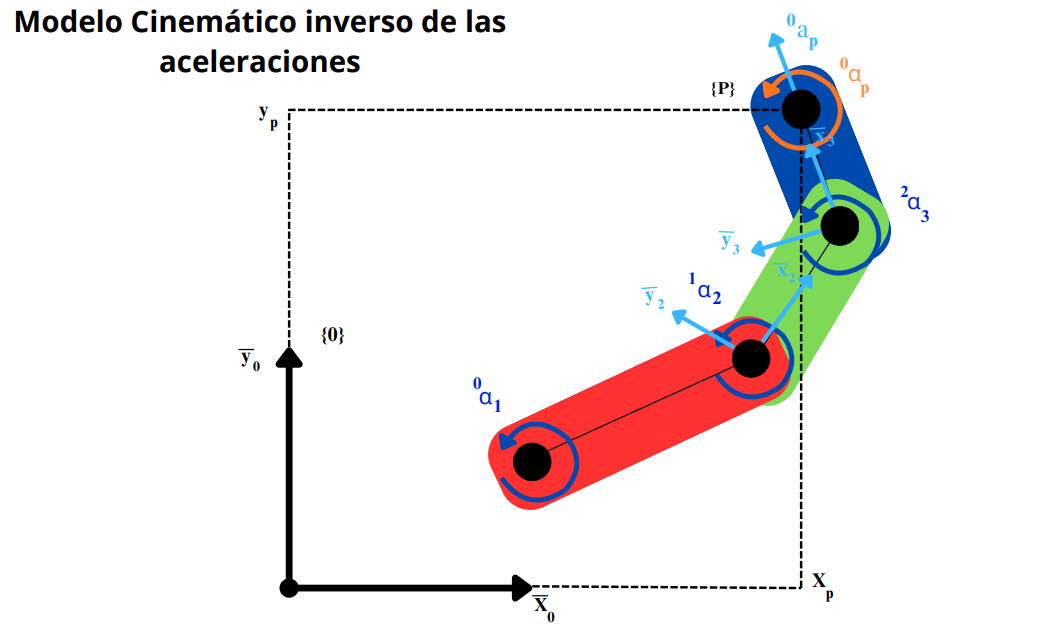
</p>


Al igual que con el modelo inverso de la velocidad, en esta sección se busca determinar los valores de las aceleraciones angulares de las juntas del robot tal que cumplan con una determinada configuración de aceleración tangencial y angular final en el punto P, expresados en el vector $\ddot{\;\xi \;} {\;}_{O,P}$.


In [30]:
syms x_ddot_O_P y_ddot_O_P theta_ddot_O_P
xi_ddot_O_P=[x_ddot_O_P;y_ddot_O_P; theta_ddot_O_P]


Del modelo directo de las aceleraciones para este robot SCARA, $\ddot{\;\xi \;} {\;}_{O,P} =\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} +J\left(q\right)\times \ddot{\;q}$, y despejando $\ddot{\;q}$, se obtiene la expresión $\ddot{\;q} =J^{-1} \left(q\right)\times \left(\ddot{\;\xi \;} {\;}_{O,P} -\dot{J} \left(q,\dot{\;q} \right)\times \dot{\;q} \right)$. De alguna forma, se podría pensar que la derivada de la definicón del modelo cinemático inverso de la velocidad $\dot{\;q} =J^{-1} \left(\theta \;\right)\dot{\;\xi \;} {\;}_{O,P}$ podría llevarnos al mismo resultado y de una forma más simple, no obstante, la matriz inversa no es derivable y en realidad genera bastante complicaciones para ser calulada de esta forma.


Por ello se opta por la primera definición presentada, tomando en cuenta que el vector $\dot{\;q} ={\left\lbrack \begin{array}{ccc} \dot{\;\theta \;} {\;}_{O,1}  & \dot{\;\theta \;} {\;}_{1,2}  & \dot{\;\theta \;} {\;}_{2,3}  \end{array}\right\rbrack }^T$ es un vector conocido. Así pues, se define el vector $\ddot{\;q}$:


In [31]:
q_ddot=simplify(J_theta\(xi_ddot_O_P-J_dot*q_dot))


En este resultado, cada renglón representa el estado que debe tomar la aceleración de cada actuador en su correpondiente eslabón de la cadena cinemática para lograr el movimento deseado al final de la cadena. Como se puede notar, el resultado es considerablemente largo y está en función de la configuración de la postura, la velocidad angular de cada junta y las aceleraciones tangenciales y angular indicada en el vector $\ddot{\;\xi \;} {\;}_{O,P}$.

## Modelo dinámico por ecuaciones de Eüler\-Lagrange
<p style="text-align:left">
   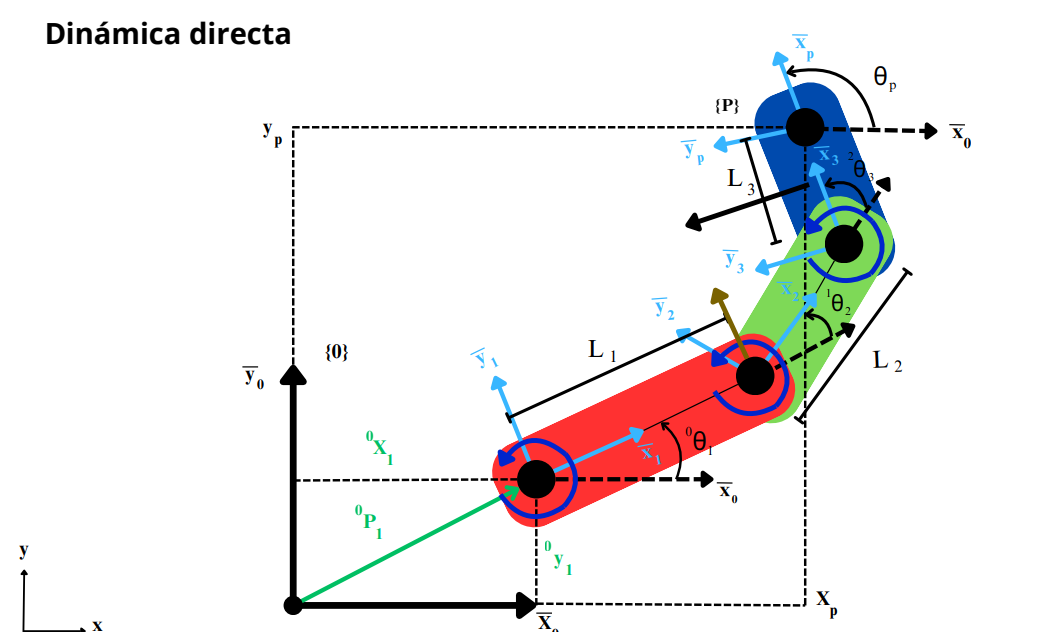
</p>


Para el modelado de la dinámica de un robot existen dos alternativas. Las opciones disponibles son el modelo dinámico de Newton\-Eüler y el modelo de Eüler\-Lagrange. Ambos modelos buscan crear una descripción de las fuerzas y los torques dentro de un robot a partir de las condiciones de movimiento, es decir, de las posiciones, de la velocidades y de la aceleraciones del robot.


El modelo de Newton\-Eüler se basa en el equilibrio de fuerzas y momentos en cada eslabón de la cadena cinemática, utilizando la descripción vectorial de las fuerzas según Newton y las ecuaciones de Eüler para la rotación. Una de sus ventajas es que dentro de su descripción podemos incluir el aporte de las fuerzas externas sobre la estructura del robot, aunque es bastante complejo debido a la inclusión de fuerzas de reacción en los puntos de apoyo y las articulaciones, complejidad que crece siempre que se aumentan los grados de libertad del robot, aunque es muy eficiente para generar un sistema de control pues es fácil de programar computacionalmente.


Por otro lado, el modelo dinámico de Eüler\-Lagrange se basa en la conservación de la energía y en cómo el sistema alterna entre energía cinética y pontencial a lo largo de su comportamiento. ESte modelo se caracteriza por incluir la cantidad llamda Lagrangiano, un escalar que contempla el cambio de la energía y que se define como $\mathcal{L}\mathcal{a}=K-U$, donde $K$ representa la suma de la energía cinética de cada cuerpo y $U$ es la energía potencial de cada elemento. Este modleo contempla a toda la cadena cinemática como un ente, compuesto sí de elementos más simples, pero que funciona como un solo sistema que contiene un solo Lagrangiano. La desventaja de este modelo es que directamente no se puede obtener de él el efecto que causan las fuerzas externas al sistema sobre sus torques, por lo que se le tienen que agregar a través de otro uso que tiene la matriz jacobiana.


En este caso, se tomará el modelado por ecuaciones de Eüler\-Lagrange debidoa a su estructura un poco más simple, pues a través de la ecuación $\tau =M\left(q\right)\ddot{\;q} +V\left(\dot{q\;} ,q\right)+G\left(q\right)+J\left(q\right)\lambda \;$, sumamente útil para establecer un sistema de control sobre los torques que tendrá cada actuador de la cadena cinemática, aunque la operación con el Lagrangiano exige mucha exactitud, pues puede ser muy significativo un error en cualquiera d elos pasos intermedios que se deben completar para llegar a la descripción final del vector de toques $\tau \;$.


A continuación, se muestra el modelo obtenido para el robot SCARA analizado en este examen.

### Cálculo del Lagrangiano

El Lagrangiano será la herramienta base para construir el modelo mencionado. Para ello, definimos los modelos matemáticos que definirán a las magnitudes físicas que lo componen. La energía cinética de cad eslabón se calculará como:


$$k_i =\frac{m_i }{2}v_{\textrm{ci}}^T v_{\textrm{ci}} +\frac{1}{2}\omega {\;}_i^T I_{\textrm{ci}} \omega {\;}_i$$

Donde, $m$ es la masa del elemento i, $v_{\textrm{ci}}$ es el vector de velocidad lineal o tangencial del centro de gravedad del elemento i, $\omega {\;}_{\textrm{ci}}$ es la velocidad angular del mismo punto y la magnitud $I_{\textrm{ci}}$ es la inercia medida en el centro de masa, que nos indica la resistencia que el eslabón i para cambiar su velocidad de rotación respecto a un eje que pasa por dicho punto, depende de la masa total del objeto y cómo está distribuida al rededor del punto de análisis.


La energía potencial, por otra parte, se calculará como:


$$u_i =-m_i g^T P_{\textrm{ci}}$$

Donde $m$ sigue siendo la masa de cada elemento, $g^T$ es el vector de aceleración gravitacional que afecta al sistema y $P_{\textrm{ci}}$ es el vector de posición al centro de masa del elemento $i$. Cabe mencionar que todos y cada uno de los vectores usados en estos cálculos, al igual que en la parte de la cinemática, deben estar descritos bajo un sistema estándar de referencia, que en este caso seguirá siendo el sistema {O}. Como la definición del cambio de la energía potencial se define como el negativo del trabajo realizado por una fuerza conservativa, se establece que el signo negativo que acompaña a la definición de la energía potencial indica que un trabajo positivo hace que disminuya la energía potencial del sistema.


Como es evidente, se deben calcular bastantes vectores que tienen una contribución en ambos modelos. Los cálculos se desarrollan en las siguientes secciones.

## Cálculo de la posición de los centros de masa
<p style="text-align:left">
   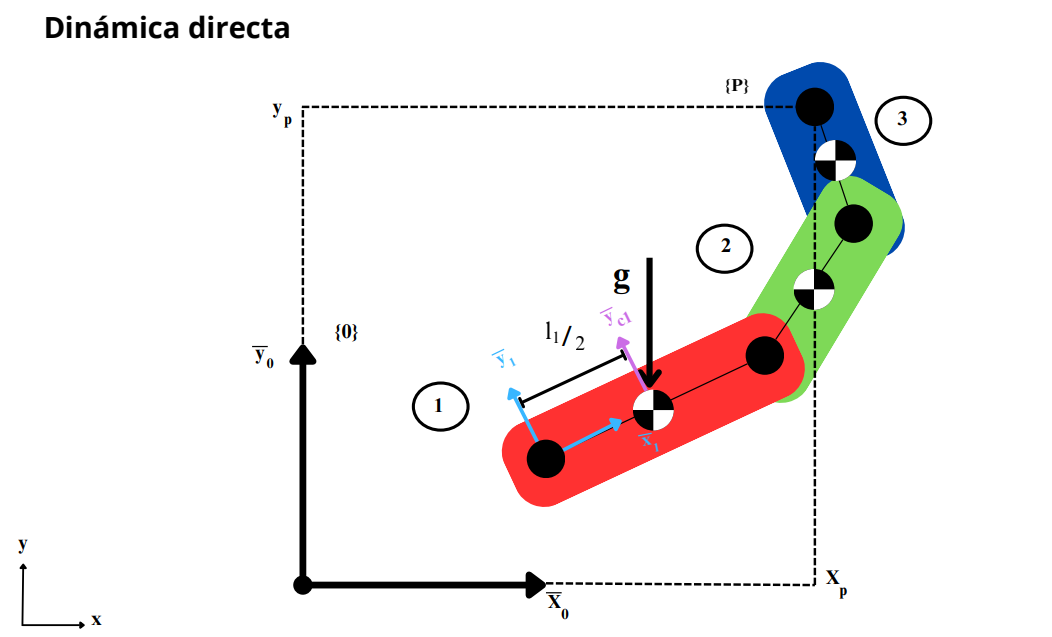
</p>


Al igual que en el caso del modelo cinemático directo de la posición y valiéndonos de los sistemas de referencia que ya tenemos, se crean nuevos sistemas de referencia desde los cuales se harán las descripciones locales. El punto sobre el cual se colocarán cada uno de los nuevos sistemas de refrencia es el centro de masa $\textrm{Ci}$ de cada eslabón. Por ello, es necesario definir nuevas funciones de tranformación que atiendan a la generación de los dichos nuevos sistemas de referencia. Como los ejes de referencia de cada junta están alineados al eje de los eslabones en su dirección $\hat{x\;}$, las transformaciones hacia los sistemas de referencia montados sobre los centros de masa serán sólo de traslación, pues mantendrán la misma orientación que sus sistemas de referencia de junta correpsondientes. Para el caso de $\left\lbrace \textrm{c1}\right\rbrace$, desde el sistema {1} se avanza una distancia $x_{1,\textrm{C1}}$, por lo que la transformación $T_{1,\textrm{C1}}$ será:


In [32]:
syms x_1_C1 x_2_C2 x_3_C3

T_1_C1 = Tij(x_1_C1,0,0,0,0,0)


Con $T_{1,\textrm{C1}}$ y atendiendo a la naturaleza de las matrices de transformación descrita en la sección del modelo cinemático directo de la posción, se obtiene $T_{O,\textrm{C1}} =T_{O,1} T_{1,\textrm{C1}}$:


In [33]:
T_O_C1 = T_O_1*T_1_C1


Aplicando la misma secuencia para $T_{2,\textrm{C2}}$ se obtiene:


In [34]:
T_2_C2 = Tij(x_2_C2,0,0,0,0,0)


Para obtener eventualmente $T_{O,\textrm{C2}} =T_{O,1} T_{1,2} T_{2,\textrm{C2}}$:


In [35]:
T_O_C2 = T_O_1*T_1_2*T_2_C2


Haciendo la correspondiente traslacaión para obtener la tranforación $T_{3,\textrm{C3}}$


In [36]:
T_3_C3 = Tij(x_3_C3,0,0,0,0,0)


Para obtener, finalmente $T_{O,\textrm{C3}} =T_{O,3} T_{3,\textrm{C3}}$, de la expresión obtenida en el modelo cinemático directo de las posiciones:


In [37]:
T_O_C3 = T_O_1*T_1_2*T_2_3*T_3_C3


Con las tranformaciones correspondientes, podemos crear los vectores de posición de los centros de masa descritos desde el sistema incercial {O}, pues sabemos que $p_{O,\textrm{Ci}} ={\left\lbrack \begin{array}{ccc} T_{O,\textrm{Ci}} \left(1,4\right) & T_{O,\textrm{Ci}} \left(2,4\right) & T_{O,\textrm{Ci}} \left(3,4\right) \end{array}\right\rbrack }^T$. Dicho esto, se presntan los vectores de posción de cada centro de masa:


In [38]:
%Vectores de posición
p_O_C1 = [T_O_C1(1,4);T_O_C1(2,4);T_O_C1(3,4)]

In [39]:
p_O_C2 = simplify([T_O_C2(1,4);T_O_C2(2,4);T_O_C2(3,4)])

In [40]:

p_O_C3 = simplify([T_O_C3(1,4);T_O_C3(2,4);T_O_C3(3,4)])


Como era de esperarse, en sí los vectores de posición de los centros de masa de cada eslabón se componen de la descripción de la posición del sistema de referencia de cada junta más una proyección de la distancia $x_{i,\textrm{Ci}}$, tanto en $\hat{x\;}$ como en $\hat{y}$.

## Cálculo de las velocidades

Como se sabe desde niveles anteriores de cursos de mecánica, la velocidad lineal se define como $v=\frac{\textrm{dp}}{\textrm{dt}}$. En este caso, teniendo ya los vectores de posición, podemos definir a los de velocidad como $v_{O,\textrm{Ci}} =\frac{{\textrm{dp}}_{O,\textrm{Ci}} }{\textrm{dt}}$. Debido a que no se ha incluido la dependencia del tiempo al movimiento del robot, podemos sustituir la derivada total por $v_{O,\textrm{C1}} =\sum_{i=1}^n \frac{\partial \;p_{O,\textrm{Ci}} }{\partial \;q_i }\dot{\;q} {\;}_i$. En nuestro caso, $n=3$ porque el vector de configuración $q$ contiene tres ángulos. Dicho esto, se pueden calcular las velociades tangenciales de los centros de masa, las cuales se muestran a continuación:


In [41]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3

v_O_C1 = diff(p_O_C1,theta_O_1)*theta_dot_O_1+diff(p_O_C1,theta_1_2)*theta_dot_1_2+diff(p_O_C1,theta_2_3)*theta_dot_2_3

In [42]:
v_O_C2 = diff(p_O_C2,theta_O_1)*theta_dot_O_1+diff(p_O_C2,theta_1_2)*theta_dot_1_2+diff(p_O_C2,theta_2_3)*theta_dot_2_3

In [43]:
v_O_C3 = diff(p_O_C3,theta_O_1)*theta_dot_O_1+diff(p_O_C3,theta_1_2)*theta_dot_1_2+diff(p_O_C3,theta_2_3)*theta_dot_2_3

### Cálculo de la velocidades angulares

Si bien en el caso de las velocidades tangenciales de los centros de masa, el efecto del movimiento de un eslabón sobre otro estaba ímplicito en cómo se contruyó la descripción de la posición del punto y por lo tanto en la derivada que define a la velocidad, en el caso de las velocidades angulares, esto se debe calcular de forma adicional. Para ello, se emplea la ecuación general:


$$\omega {\;}_{i,i} =R_{i,i-1} \omega {\;}_{i-1,i-1} +\hat{n} \dot{\;\theta \;} {\;}_{i-1,i}$$

Ecuación en la que se calcula la velocidad angular de un eslabon $i$, gracias a la suma de la velocidad angular del eslabón anterior, pero que al estar descrito desde su propio sistema de referencia, se debe premultiplicar por la matriz de rotación $R_{i,i-1}$ que nos permite pasar del sistema $i-1$ al sistema de referencia $i$, en el que nos es de sumo interés tener la velocidad angular total previa para sumarle el efecto de la velocidad angular $\dot{\theta \;} {\;}_i$ del eje de rotación $\hat{n} {\;}_i$ de la junta rotacional que genera el movimento nuevo al eslabón $i$.


Para el primer eslabón:


In [44]:
syms omega_1_1 omega_2_2 omega_3_3
%Propagación para el primer cuerpo
omega_1_1;


Como no existe un eslabón previo a este, es decir, está montado sobre una base que no rota, entonces $\omega {\;}_{O,O}$ es un vector nulo.


In [45]:
omega_O_O = [0;0;0]

omega_O_O = 3x1
     0
     0
     0



Como es un caso de estudio plano, las rotaciones siempre se harán sobre el eje $\hat{z\;}$, independientemente de cuál sea el sistema analizado.


In [46]:
n_1_1 = [0;0;1]

n_1_1 = 3x1
     0
     0
     1



De la matriz de transformación analizada en la sección de la cinemática directa de la posición, obtenemos que


$$R_{O,i} =\left\lbrack \begin{array}{ccc} T_{O,i} \left(1,1\right) & T_{O,i} \left(1,2\right) & T_{O,i} \left(1,3\right)\newline T_{O,i} \left(1,2\right) & T_{O,i} \left(2,2\right) & T_{O,i} \left(2,3\right)\newline T_{O,i} \left(1,3\right) & T_{O,i} \left(2,3\right) & T_{O,i} \left(3,3\right) \end{array}\right\rbrack$$

Por lo que cada matriz de rotación se construirá así:


In [47]:
R_O_1 = [T_O_1(1,1),T_O_1(1,2),T_O_1(1,3);T_O_1(2,1),T_O_1(2,2),T_O_1(2,3);T_O_1(3,1),T_O_1(3,2),T_O_1(3,3)]


No obstante, en este caso no se necesita pasar de un sistema $\left\lbrace n\right\rbrace$ a un sistema $\left\lbrace n-1\right\rbrace$, que es lo que esta matriz genera, si no, se debe pasar de un sistema $\left\lbrace n-1\right\rbrace \;a\;\textrm{uno}\;\left\lbrace n\right\rbrace$. Por lo tanto, se necesitan las matrices inversas de rotación, pero al ser tranformaciones homógeneas, basta con transponer las matrices de rotación obtenidas. Por ello, $R_{1,O}$ será:


In [48]:
R_1_O = transpose(R_O_1)


Con todos lo vectores y la matriz de rotación definidos para calcular $\omega {\;}_{1,1}$, se procede a obtener e vector que lo define:


In [49]:
%Ecuación de propagación
omega_1_1 = R_1_O*omega_O_O+n_1_1*theta_dot_O_1


Para el segundo cuerpo se repite el mismo proceso.


In [50]:
%Propagación para el segundo cuerpo
omega_2_2;
n_2_2 = [0;0;1];


El vector $\hat{n}$ tiene la misma forma que en el primer caso por la razón brindada. Se obtiene la matriz de rotación del sistema {2} respecto al sistema {1} para eventualmente invertirla.


In [51]:
R_1_2 = [T_1_2(1,1),T_1_2(1,2),T_1_2(1,3);T_1_2(2,1),T_1_2(2,2),T_1_2(2,3);T_1_2(3,1),T_1_2(3,2),T_1_2(3,3)]

In [52]:
R_2_1 = transpose(R_1_2)


En este caso, queda claro que la velocidad angular previa a $\omega {\;}_{2,2}$ es $\omega {\;}_{1,1}$, de tal forma que el cálculo final nos brinda:


In [53]:
%Ecuación de propagación
omega_2_2 = R_2_1*omega_1_1+n_2_2*theta_dot_1_2


Repitiendo lo mismos pasos para $\omega {\;}_{3,3}$, se obtiene la matriz de rotación desde $T_{O,3}$, para después transponerla.


In [54]:
%Propagación para el tercer cuerpo
omega_3_3;
n_3_3 = [0;0;1];
R_2_3 = [T_2_3(1,1),T_2_3(1,2),T_2_3(1,3);T_2_3(2,1),T_2_3(2,2),T_2_3(2,3);T_2_3(3,1),T_2_3(3,2),T_2_3(3,3)]

In [55]:
R_3_2 = transpose(R_2_3)


Se obtiene finalmente la $\omega {\;}_{3,3}$, teniendo en cuneta que la velocidad angular del eslabón anterior a este es $\omega {\;}_{2,2}$.


In [56]:
%Ecuación de propagación
omega_3_3 = R_3_2*omega_2_2+n_3_3*theta_dot_2_3

In [57]:
v_O_C3;

## Defición de los elementos de inercia

Otras herramientas que necesitamos definir son los elementos de inercia de cada eslabón. Aunque de forma general las matrices de inercia constan de 9 elementos, estas pueden simplificarse si su descripción se hace desde sistemas de referencia que coincidan con lo ejes principales de rotación del elemento analizado. Como en nuestro caso, cada objeto está siendo analizado desde sus centro de masa para eventualemente llevarlo a una descripción general, estas matrices se volverán matrices diagonales en las que solo tendremos la información de cómo rota cada objeto respecto a sus ejes principales alineados con los ejes del sistema de referencia del centro de masa, sin información extra de los llamados productos de inercia que brindan información sobre la asimetría o la distribución no uniforme de masa. Las tres matrices de incercia de inteés se muestran a continuación.


In [58]:
syms g I_xx1 I_yy1 I_zz1 I_xx2 I_yy2 I_zz2 I_xx3 I_yy3 I_zz3
%vector de gravedad

I_C1 = [I_xx1,0,0;0,I_yy1,0;0,0,I_zz1]

In [59]:
I_C2 = [I_xx2,0,0;0,I_yy2,0;0,0,I_zz2]

In [60]:
I_C3 = [I_xx3,0,0;0,I_yy3,0;0,0,I_zz3]


En esta sección se aprovecha el espacio para definir al vector de gravedad $g$, el cual sólo tiene componente en la dirección $\hat{y\;}$.


In [61]:
g_v = [0;-g;0]

### Cáculo de la Energía Cinética y Potencial de cada cuerpo

Con los elementos calculados en las secciones anteriores, ahora se pueden aplicar las definiciones mostradas en la introcucción de todo estre procedimiento, $k_i =\frac{m_i }{2}v_{\textrm{ci}}^T v_{\textrm{ci}} +\frac{1}{2}\omega {\;}_i^T I_{\textrm{ci}} \omega {\;}_i$ y $u_i =-m_i g^T P_{\textrm{ci}}$. De tal forma que, obtenemos las siguientes energías:


Energía cinética del primer eslabón $k_1$


In [62]:
syms m_1 m_2 m_3
%energía cinética de cada uno de los cuerpos

k_1 = simplify((m_1/2)*transpose(v_O_C1)*v_O_C1+(1/2)*transpose(omega_1_1)*I_C1*omega_1_1)


Energía cinética del primer eslabón $k_2$


In [63]:
k_2 = simplify((m_2/2)*transpose(v_O_C2)*v_O_C2+(1/2)*transpose(omega_2_2)*I_C2*omega_2_2)


Energía cinética del primer eslabón $k_3$


In [64]:
k_3 = simplify((m_3/2)*transpose(v_O_C3)*v_O_C3+(1/2)*transpose(omega_3_3)*I_C3*omega_3_3)


En los resultados de la energía cinética se logra apreciar que, a medida que se avanza de la base del robot hacia el final de la cadena cinemática aumenta la complejidad de la energía cinética. En el primer eslabón no existe una contribución además del actuador de su junta que genera un movimiento, mientras que en el último eslabón, queda claro que la energía cinética está determinada por la contribución del movimento de los dos eslabones previos a él.


In [65]:
% Cáclulo de la energía potencial de cada cuerpo


A continuacón, se muestran las enegías potenciales $u_1 ,u_2 \;y\;u_3 :$


In [66]:
u_1 = -m_1*transpose(p_O_C1)*g_v

In [67]:
u_2 = -m_2*transpose(p_O_C2)*g_v

In [68]:
u_3 = -m_3*transpose(p_O_C3)*g_v


En estos resultados se aprecia que no es tan compleja la definición de la energía potencial porque sólo aumenta la descripción de la pocisión del centro de masa.

### Cálculo del Lagrangiano

Con las energías cinéticas y potenciales de cada eslabón, se define al Lagrangiano $\mathcal{L}\mathcal{a}=\sum_{i=1}^n k_i -\sum_{i=1}^n u_i$. En este caso de análisis, $n=3$. Sumando directamente cada resultado del punto anterior, se obtiene la descripción del comportamiento enérgetico del sistema, tal que:


In [69]:
La = (k_1+k_2+k_3)-(u_1+u_2+u_3)

## Cálculo de los pares

De forma general, con el cálculo del Lagrangiano ya se puede obtener el el modelo dinámico del robot, una ecuación que nos brinde la información de los pares dentro de la cadena cinemática del robot.


Los pares dentro del robot se definen como $\tau {\;}_i =\frac{d}{\textrm{dt}}\left(\frac{\partial \;\textrm{La}}{\partial \;\dot{\;q} {\;}_i }\right)-\frac{\partial \;\textrm{La}\;}{\partial \;q_i }$. Esta definición nos indica que los pares son el resultado del cambio en el tiempo de la taza de cambio de la energía dentro del sistema cuando una junta rotacional se mueve a una velocidad menos el cambio de la energía cuando el robot cambia de posición.


De nuevo, debido a que aún no se incluye a la varible tiempo como un componente que determine el efecto del robot, la ecuación puede expandirse de la sieguente forma:


$$\tau {\;}_i =\sum_{j=1}^n \frac{\partial \;\;}{\partial \;q_j }\left(\frac{\partial \;\textrm{La}}{\partial \;\dot{\;q} {\;}_i }\right)\dot{\;q} {\;}_j +{\sum_{j=1}^n \frac{\partial \;\;}{\partial \;{\dot{\;q} }_j }\left(\frac{\partial \;\textrm{La}}{\partial \;\dot{\;q} {\;}_i }\right)\ddot{\;q} }_j -\frac{\partial \;\textrm{La}}{\partial \;q_i }$$

Por ello, para calcular, por ejemplo, el primer par (correpondiente a la primera junta, donde se una la base del robot y el primer eslabón), de obtiene la diferencial del Lagrangiano respecto a la velocidad de la junta, es decir, $\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }$, resultado que se muetsra a continucación.


In [70]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3

D_theta1 = diff(La,theta_dot_O_1)


Ahora, se puede calcular a $\tau {\;}_1$, con $\tau {\;}_1 =\frac{\partial \;}{\partial \;\theta {\;}_{O,1} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\dot{\theta \;} {\;}_{O,1} +\frac{\partial \;}{\partial \;\theta {\;}_{1,2} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\dot{\theta \;} {\;}_{1,2} ++\frac{\partial \;}{\partial \;\theta {\;}_{2,3} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\dot{\theta \;} {\;}_{2,3} +\frac{\partial \;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\ddot{\;\theta \;} {\;}_{O,1} +\frac{\partial \;}{\partial \;\dot{\;\theta \;} {\;}_{1,2} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\ddot{\;\theta \;} {\;}_{1,2} ++\frac{\partial \;}{\partial \;\dot{\;\theta \;} {\;}_{2,3} }\left(\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{O,1} }\right)\ddot{\;\theta \;} {\;}_{2,3} -\frac{\partial \;\textrm{La}}{\partial \;\theta {\;}_{O,1} }$. Con lo que se obtiene:


In [71]:
% Cálculo de relación

tao_1 = diff(D_theta1,theta_O_1)*theta_dot_O_1 + diff(D_theta1,theta_1_2)*theta_dot_1_2 + diff(D_theta1,theta_2_3)*theta_dot_2_3 + diff(D_theta1,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta1,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta1,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_O_1)


Aplicando los mismos conceptos para $\tau {\;}_2$, $\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{1,2} }$ queda definida como:


In [72]:
D_theta2 = diff(La,theta_dot_1_2)


Y el calculo completo de $\tau {\;}_2$ queda expresado como:


In [73]:
tao_2 = diff(D_theta2,theta_O_1)*theta_dot_O_1 + diff(D_theta2,theta_1_2)*theta_dot_1_2 + diff(D_theta2,theta_2_3)*theta_dot_2_3 + diff(D_theta2,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta2,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta2,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_1_2)


Repitiendo el proceso para $\tau {\;}_3$, $\frac{\partial \;\textrm{La}\;}{\partial \;\dot{\;\theta \;} {\;}_{2,3} }$ queda como:


In [74]:
D_theta3 = diff(La,theta_dot_2_3)


Lo que nos lleva finalmente al valor del último par de la cadena cinemática:


In [75]:
tao_3 = diff(D_theta3,theta_O_1)*theta_dot_O_1 + diff(D_theta3,theta_1_2)*theta_dot_1_2 + diff(D_theta3,theta_2_3)*theta_dot_2_3 + diff(D_theta3,theta_dot_O_1)*theta_ddot_O_1+ diff(D_theta3,theta_dot_1_2)*theta_ddot_1_2+ diff(D_theta3,theta_dot_2_3)*theta_ddot_2_3-diff(La,theta_2_3)


Gracias a estos cálculos, se puede crear el vector de pares total $\tau :$


In [76]:
tao = [tao_1;tao_2;tao_3]


Este vector contine el valor escalar del torque de cada actuador de las juntas que es capaz de mover la masa de los eslabones, no obstante, es difícil constatar la contibución de cada efecto de fuerza, movimiento y campo gravitacional en esta definición de los pares, por ello se buscará la separación de este resultado en una expresión matricial, en la que también se sume el efecto de las fuerzas externas de contacto.


El vector resultante es $\tau =\tau \;\left(q,\dot{\;q} ,\ddot{\;q} ,g\right)$

## Modelo dinámico directo
### Matriz de Inercia

Para conocer la aportación que cada eslabón brinda a la inercia de la cadena cinemática del robot, se tomará el resultado anterior del vector de pares y se buscarán los valores que sólo dependen de la aceleración del primer acutador, es decir, $\ddot{\;\theta \;} {\;}_{O,1}$.


In [77]:
% Cálculo de la matriz de inercia

M1 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[1,0,0,0,0,0,0])


Ahora se busca la aportación del segundo eslabón:


In [78]:
M2 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,1,0,0,0,0,0])


Y por último:


In [79]:
M3 = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,1,0,0,0,0])


Los resultados obtenidos se muestran en la matriz $M\left(q\right)$:


In [80]:
M_theta = collect([M1 M2 M3],[m_1,m_2,m_3])


Esta matriz representa en total cómo se distribuye la masa del robot a lo largo de la cadena cinemática y depende únicamente de la configuración de postura, y ayuda a medir la resitencia que ofrece el robot al cambio de la velocidad, ya sea lineal o angular. En la ecuación general de la dinámica directa del robot, este término está multiplicado por el vector $\ddot{\;q}$, lo que sabemos que resulta en un vector de pares, resultado de la aceleración angular con la que, un cuerpo de inercia contenida en la descripción $M\left(\theta \;\right)$, va a moverse.

### Cálculo del Vector de Pares de Coriolis y Fuerzas Centrífugas

El vector de pares de Coriolis y fuerzas centrífugas es un vector que depende de los términos de la velocidad angular del sistema. Cuantifica el efecto en las fuerzas que provocan las aceleraciones hacia un lugar fuera del sistema sobre los eslabones, así como el efecto de la suma de adición física de velocidades, es decir, cuando un eslabón se mueve a una velocidad mientras el eslabón al que se sujeta ya se estaba moviendo. En estrcito sentido, este vector debería depender, al igual que $\tau \;$, de el vector de pose, velocidad y aceleración angular, aunque otra forma de expresarlo es como una matriz de fuerzas de Coriolis multiplicado por el vector de velocidades angulares, tal que $C\left(q,\dot{\;q} \right)\dot{q}$.


In [81]:
syms F_x F_y F_z
V_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,0])

### Cálculo de Vector de Gravedad

De la misma forma que con las matrices de inercia y el vector de pares anteriores, del vector $\tau \;$ se extrae la información que depende de la magnitud de la aceleración gravitacional. Representa las fuerzas que debe agregar el motor por el hecho de sujetar eslabones con masa inmersos en un sistema gravitacional.


In [82]:
G_theta = subs(tao,[theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3,theta_dot_O_1,theta_dot_1_2,theta_dot_2_3,g],[0,0,0,0,0,0,g])

### Cálculo de Pares por Fuerzas Externas

Cuando el extremo de un robot interactúa con un objeto del mundo, se dice que colisiona. Dicha colisión viene acompañada de fuerzas resultantes que el robot también debe ser capaz de soportar y vencer para asegurar una movilidad exitosa. Debido a esto y dado a que esto no se calcula dentro del vector $\tau \;$ de pares, se debe agragar el vector de fuerzas de colisión $\lambda \;$:


In [83]:
lambda=[F_x; F_y; F_z]


Este vector de fuerzas entra de forma matemática a la descripción del robot gracias a la matriz Jacobiana. El resultado final de los pares puede ser espresado como $\tau {\;}_T =\tau +\tau {\;}_G$, donde el vector de pares total es el resulatado de sumarle los pares generados por las fuerzas de colisión al resultado incial de los pares internos del robot.


De forma matricial, el vector de pares total queda definido como $\tau_T =M\left(q\right)\ddot{\;q} +V\left(q,\dot{\;q} \right)+G\left(q\right)+J\left(\theta \right)\lambda \;$. El resultado de esta ecuación con todos los elemntos calculados previamente se muestra a continuación:


In [84]:
q_ddot = [theta_ddot_O_1; theta_ddot_1_2; theta_ddot_2_3];
tau_T=M_theta*q_ddot+V_theta+G_theta+J_theta\lambda


Con esta descripción directa de la dinámica del robot, se puede calcular el par necesario de cada motor que se monte en cada junta para asegurar un movimieento continuo y efectivo bajo las condiciones de carga debidas a la configuración interna de los eslabones, así como sus propiedades físicas y mecánicas, además de las provocadas por la colición del robot con objetos ajenos a la cadena cinemática.

### Cálculo del modelo Dinámico inverso
<p style="text-align:left">
   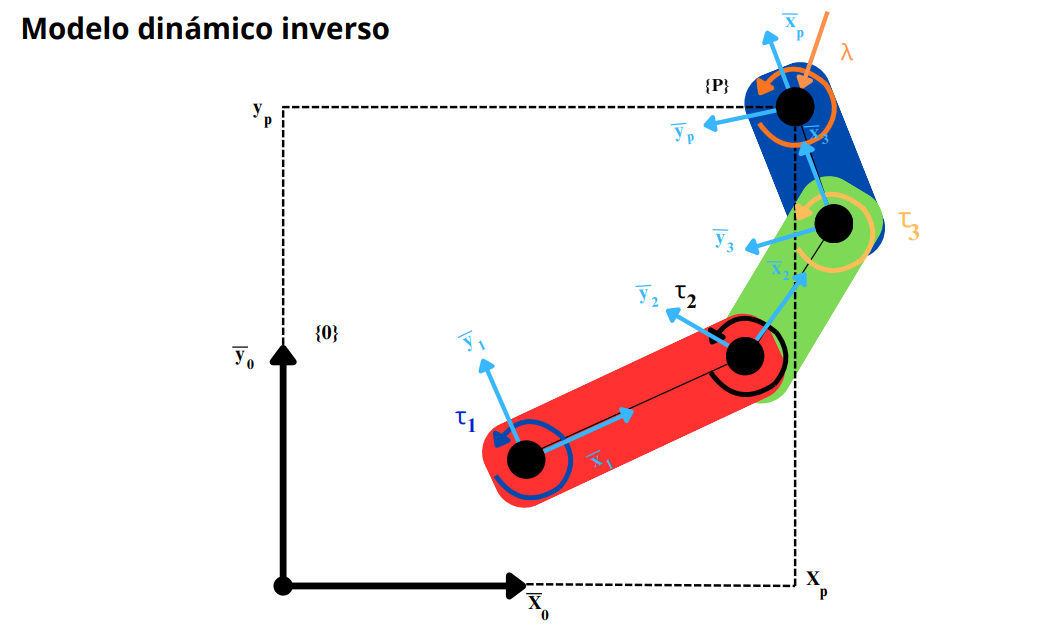
</p>


Bajo la siguiente situación en la que se conoce perfectamente los pares con los que operarán usualmente todos los actuadores del robot, se tiene un vector conocido $\tau \;$, pero se desea determinar cuáles serán las fuerzas externas que puede soportar el robot con esta configuración de eslabones y motores.


In [85]:
syms tau_1 tau_2 tau_3
tau_T=[tau_1;tau_2;tau_3]


Del modelo dinámico directo, se puede despejar a $\lambda \;$, $J\left(\theta \;\right)\lambda =\tau -M\left(q\right)\ddot{\;q} -V\left(q,\dot{\;q} \right)-G\left(q\right)$, entonces, se obtendrá finalmente: $\lambda =J^{-1} \left(\theta \right)\left(\tau -M\left(q\right)\ddot{\;q} -V\left(q,\dot{\;q} \right)-G\left(q\right)\right)$. La matriz Jacobiana inversa determina la conversió desde el sistema interno del robot hacia la descripción en el sistema inercial de las fuerzas de colisión. Calculando este resultado, $\lambda \;$ será:


In [86]:
lambda=inv(J_theta)\(tau_T-M_theta*q_ddot-V_theta-G_theta)

## Conclusión

De manera simbolica se han calculado todos los resultados esperados de este examen. Aunque de forma general, algunos resultados son sumamente complejos y tienden a ser bastante dificiles de analizar, se ha hecho el esfuerzo de sí analizarlos y encontrar un sentido a las expresiones obtenidad. Debido a esto y a la programación cuidadosa que se ha hecho, se puede afirmar que los resultados son satisfactorios y que contemplan un comportamiento generalemtne estable del robot, aunque las singularidades matemáticas son un caso normal en estos casos, debido a la existencia de momentos en los que la matriz jacobiana pierda elemento o casos en los que, por ejemplo, para la cinemática inversa de las posiciones, existen resultaods que no son posibles en la vida real o existen muchas configuraciones de ángulos que aseguran llegar a la postura deseada.


Se ha trabajado sistemáticamentemente para generar los reusltados deseados, estableciendo la relaciones entre la cinemática y la dinámica del robot de tal forma que se han logrado expresiones útiles para simular y controlar el robot bajo distintos escenarios. La creación de este documento ha dejado la correcta comprensión de los temas necesarios para realizar todas y cada una de las subsecciones de los modelos de la mecánica del robot. Aunque fue algo nuevo trabajar de esta forma con todo los resultados, a la vez que se documentaba cada parte del proceso, considero que fue un gran ejercicio para aprender mcuhas cosas, tanto en lo teórico como en lo práctico, al usar distintas herramientas de software como Matlab.

